In [1]:
import pandas as pd
import pickle as pkl
import numpy as np
import itertools
import random

In [2]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2sent_n200_notransform.pkl", 'rb') as f: 
    gene2sent_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)

id2gene_map = {i:g for g,i in gene2id_map.items()}
id2gene_map[-1]="pad"

def get_gene_sent(g_id, cancer, n=10):
    g_sent_idx = gene2sent_map[cancer][g_id]
    g_sent = [id2gene_map[g-1] for g in g_sent_idx][:n]

    return g_sent

In [3]:
### 1. Determine the list of genes that we are comparing their co-expressed genes across contexts
### They should appear at least twice across all cancers

from collections import Counter

all_gene_ids = [list(gene2sent_map[i].keys()) for i in range(8)]
counts = Counter(i for ids in all_gene_ids for i in set(ids))
# Get genes appearing in at least 2 cancers
filt_gene_ids = [elem for elem, cnt in counts.items() if cnt >= 2]

len(filt_gene_ids)

12574

In [4]:
def compute_avg_jaccard(filt_gene_ids, sent_len=10):
    ## sent_len should <= 200
    jaccard_avg_allgenes = []
    for g_id in filt_gene_ids:
        co_exp_set = []
        for c in range(8):
            if g_id in gene2sent_map[c]:
                sent = gene2sent_map[c][g_id][:sent_len]
                sent = [i for i in sent if i != -1] ## remove paddings
                if len(sent) <= 2:
                    continue
                co_exp_set.append(set(sent))
        
        ## average across each pairs of contexts
        jaccard_all = []
        for i,j in itertools.combinations(range(len(co_exp_set)), 2):
            set_i, set_j = co_exp_set[i], co_exp_set[j]
            jaccard = len(set_i & set_j) / len(set_i | set_j)
            jaccard_all.append(jaccard)
        
        jaccard_avg = np.mean(jaccard_all)
        jaccard_avg_allgenes.append(jaccard_avg)
    
    return jaccard_avg_allgenes

In [5]:
jaccard_avg_allgenes = compute_avg_jaccard(filt_gene_ids[:10], sent_len=10)

In [6]:
jaccard_avg_all_length = {}
for sent_len in [10,20,30,50,100,200]:
    jaccard_avg = compute_avg_jaccard(filt_gene_ids, sent_len=sent_len)
    jaccard_avg_all_length[sent_len] = jaccard_avg


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
def plot_violin(data):

    df_all = pd.DataFrame([(k, v) for k, values in data.items() for v in values],
                        columns=["Gene sentence length", "Avg. Jaccard similarity"])
    plt.figure(figsize=(10, 6), dpi=300)
    ax = sns.violinplot(
        x="Gene sentence length",
        y="Avg. Jaccard similarity",
        data=df_all,
        cut=0,
        inner="quart",
        bw=0.3,
        linewidth=1,
        # color="#2ca02c",
    )

    # Clip the right half of each violin to make it one-sided
    for violin in ax.collections:
        path = violin.get_paths()[0]
        vertices = path.vertices
        mean_x = vertices[:, 0].mean()
        vertices[:, 0] = np.maximum(vertices[:, 0], mean_x)

    plt.xlabel("Size of Co-expressed Gene Sets (used in Gene Sentences)", fontsize=14)
    plt.ylabel("Avg. Jaccard Similarity", fontsize=14)
    plt.title("Avg. Jaccard similarity between co-expressed gene sets across cancer types")
    plt.tight_layout()
    plt.show()
    

/tmp/ipykernel_1878249/4191159227.py:6: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.3`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


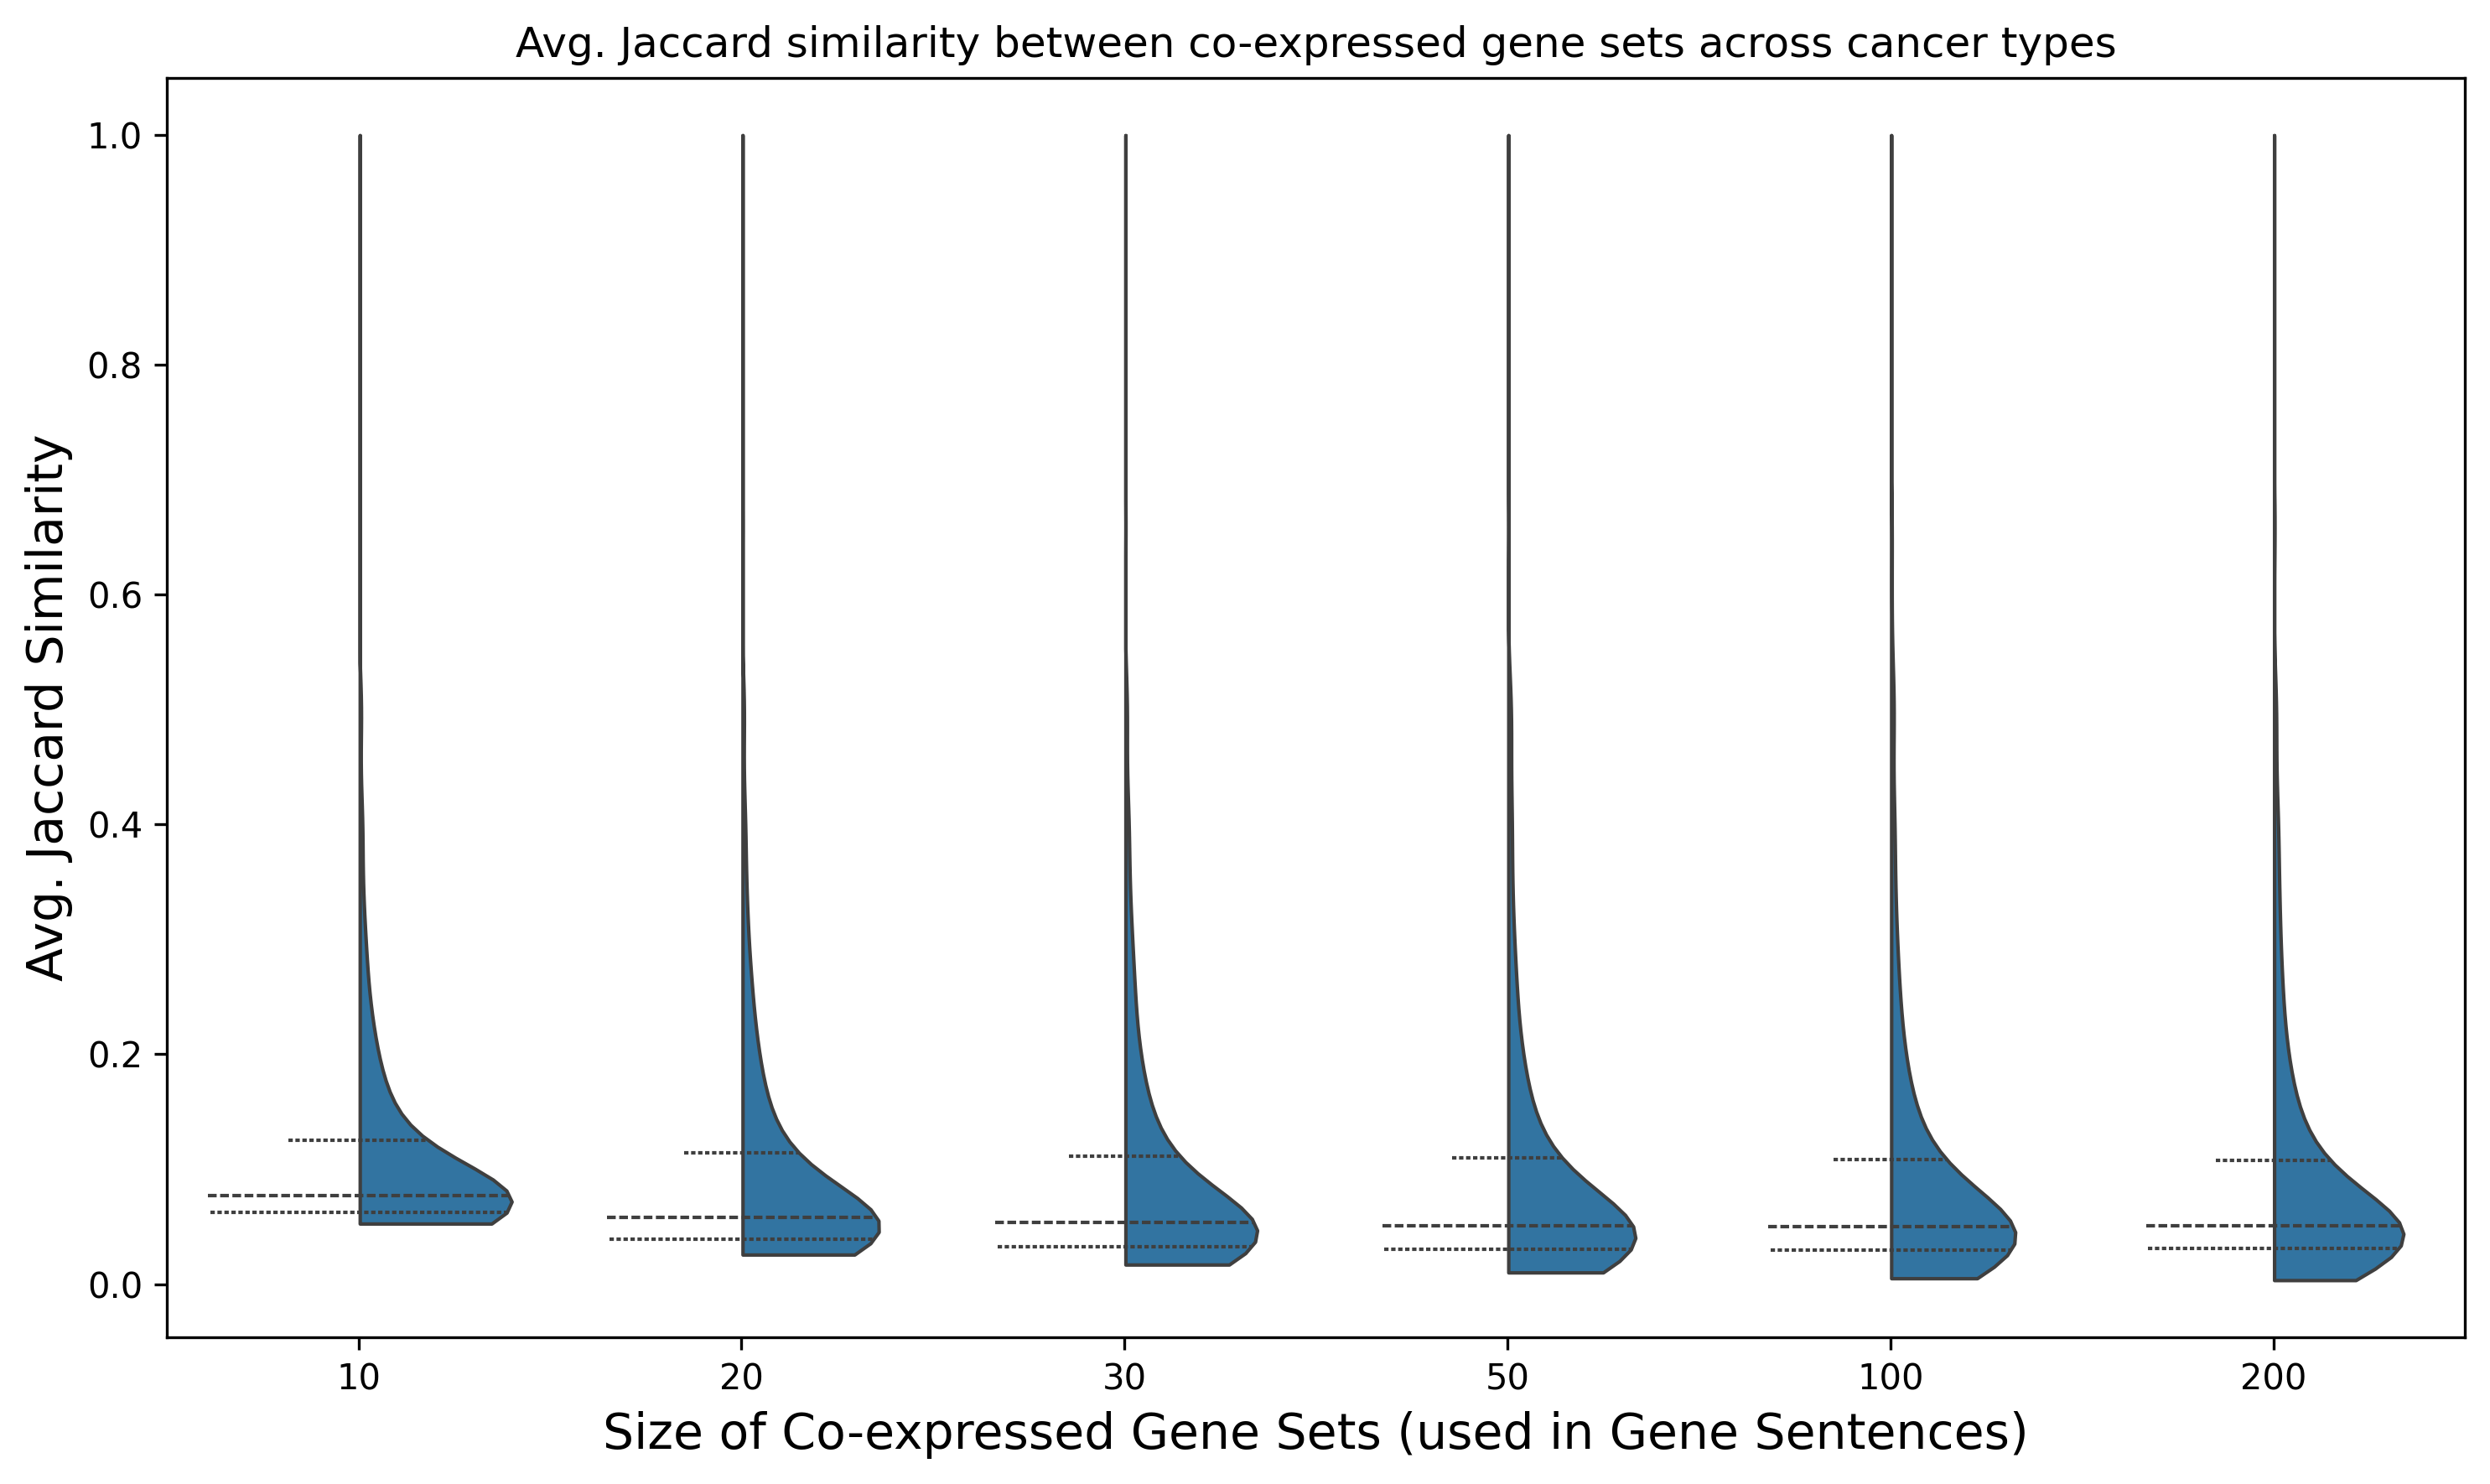

In [11]:
plot_violin(jaccard_avg_all_length)